## Data loading

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import pickle

In [3]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [4]:
def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    # sorted() -> deterministic order, so row i is always bbdd_i (the ground truth uses these indices)
    for file in sorted(os.listdir(dataset_dir)):

        # Ignore anything that is not an image or a label (e.g. gt_corresps.pkl)
        if not file.lower().endswith((".jpg", ".txt")):
            continue

        # Get filename without extension
        filename = os.path.splitext(file)[0]

        # Create entry if it doesn't already exist
        if filename not in data:
            data[filename] = {
                "image_path": None,
                "image": None,
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            data[filename]["image"] = cv2.imread(image_path)

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            with open(txt_path, "r", encoding="utf-8") as f:
                content = f.read().strip()

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = lines[0]
                    data[filename]["artwork_name"] = lines[1]

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [5]:
dataset = build_dataset(TRAIN_DIR)

In [6]:
dataset.head()

,image_path,image,artist,artwork_name
0,data/BBDD\bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes
1,data/BBDD\bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room
2,data/BBDD\bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",Unknown,Unknown
3,data/BBDD\bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth
4,data/BBDD\bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV


## Basic histogram construction and plotting

In [7]:
BINS = 128

In [8]:
def compute_histogram(img, bins=BINS):
    """
    Concatenated per-channel (B, G, R) histogram, normalised so that every channel sums to 1.
    Normalising makes the descriptor independent of image resolution (query and database images
    have different sizes), which is essential for Intersection and Chi-squared.
    """
    channels = []
    for c in range(3):
        h = np.histogram(img[:, :, c], bins=bins, range=(0, 256))[0].astype(np.float32)
        channels.append(h / h.sum())
    return np.concatenate(channels).astype(np.float32)


valid_images = dataset["image"].apply(
    lambda img: isinstance(img, np.ndarray)
    and img.ndim == 3
    and img.shape[2] == 3
)

# Dropping rows would shift the row positions and break the ground-truth indices
assert valid_images.all(), f"{(~valid_images).sum()} training images failed to load"

dataset["histogram"] = dataset["image"].apply(lambda img: compute_histogram(img, BINS))

In [9]:
dataset.head()

,image_path,image,artist,artwork_name,histogram
0,data/BBDD\bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes,"[0.032930512, 0.022737205, 0.025816858, 0.0264..."
1,data/BBDD\bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,data/BBDD\bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",Unknown,Unknown,"[0.012184508, 0.026544822, 0.04148344, 0.03997..."
3,data/BBDD\bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth,"[0.0070142364, 0.0046605514, 0.0051403833, 0.0..."
4,data/BBDD\bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV,"[0.00016688254, 8.309789e-05, 0.00013803864, 0..."


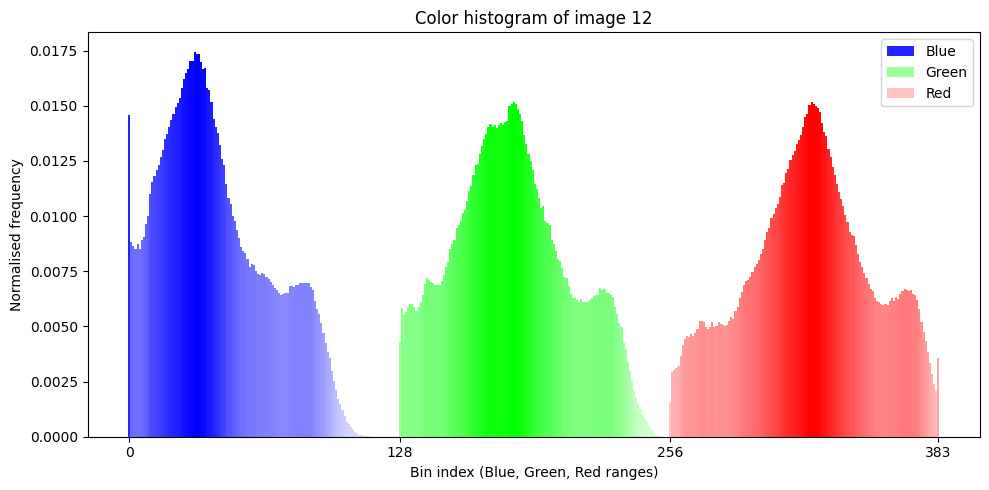

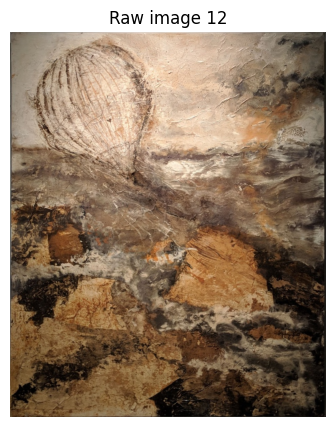

In [10]:
# Plot the histogram of the first image with one color per channel
histogram = np.asarray(dataset["histogram"].iloc[12])
channel_histograms = np.split(histogram, 3)
# OpenCV loads images as BGR, so channel 0 is Blue and channel 2 is Red
channel_colors = [(0, 0, 1), (0, 1, 0), (1, 0, 0)]
channel_names = ["Blue", "Green", "Red"]

plt.figure(figsize=(10, 5))
for channel_index, (channel_histogram, color, name) in enumerate(
    zip(channel_histograms, channel_colors, channel_names)
):
    x_values = np.arange(channel_index * BINS, (channel_index + 1) * BINS)
    maximum_frequency = channel_histogram.max()
    intensities = (
        channel_histogram / maximum_frequency
        if maximum_frequency > 0
        else np.zeros_like(channel_histogram, dtype=float)
    )
    bar_colors = [(*color, 0.15 + 0.85 * intensity) for intensity in intensities]
    plt.bar(x_values, channel_histogram, color=bar_colors, width=1.0, label=name)

plt.title("Color histogram of image 12")
plt.xlabel("Bin index (Blue, Green, Red ranges)")
plt.ylabel("Normalised frequency")
plt.xticks([0, BINS, 2 * BINS, 3 * BINS - 1])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.title("Raw image 12")
plt.imshow(cv2.cvtColor(dataset["image"].iloc[12], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Similarity measure function

In [ ]:
# Metrics where a LARGER value means "more similar". For the others (Chi-squared, Bhattacharyya)
# a SMALLER value means "more similar", so the ranking must be ascending.
HIGHER_IS_BETTER = {cv2.HISTCMP_CORREL, cv2.HISTCMP_INTERSECT}


def find_similar_images(target_image, dataset, top_n=5, method=cv2.HISTCMP_CORREL, plot=False, bins=256):
    """
    Find the most similar images in the dataset based on histogram comparison.

    Parameters:
    target_image (np.ndarray): The target image (BGR).
    dataset (pd.DataFrame): The dataset containing images and their histograms (same `bins`).
    top_n (int): The number of most similar images to return.
    method (int): cv2.HISTCMP_* comparison method.
    plot (bool): Plot the target and the retrieved images.
    bins (int): Number of histogram bins (must match the dataset histograms).

    Returns:
    pd.DataFrame: A DataFrame containing the top N most similar images and their scores.
    """
    target_histogram = compute_histogram(target_image, bins)

    # Use the requested method (it was hard-coded to HISTCMP_CORREL before)
    scores = dataset["histogram"].apply(
        lambda hist: cv2.compareHist(target_histogram, hist, method)
    )

    # Correlation / Intersection: high = similar. Chi-squared / Bhattacharyya: low = similar.
    ascending = method not in HIGHER_IS_BETTER
    top_scores = scores.sort_values(ascending=ascending, kind="stable").head(top_n)

    # Build the result without writing a "similarity" column into the shared dataset
    similar_images = dataset.loc[top_scores.index].copy()
    similar_images["similarity"] = top_scores

    if plot:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, top_n + 1, 1)
        plt.imshow(cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB))
        plt.title("Target Image")
        plt.axis("off")

        for i, (_, row) in enumerate(similar_images.iterrows(), start=2):
            plt.subplot(1, top_n + 1, i)
            plt.imshow(cv2.cvtColor(row["image"], cv2.COLOR_BGR2RGB))
            plt.title(f"Sim: {row['similarity']:.4f}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    return similar_images[["image_path", "artist", "artwork_name", "similarity"]]

In [12]:
test_dataset = build_dataset(TEST_DIR)

In [13]:
test_dataset.head()

,image_path,image,artist,artwork_name
0,data/qsd1_w1\00000.jpg,"[[[177, 187, 187], [184, 194, 194], [190, 199,...",None,None
1,data/qsd1_w1\00001.jpg,"[[[179, 191, 191], [187, 199, 199], [192, 201,...",None,None
2,data/qsd1_w1\00002.jpg,"[[[151, 170, 178], [149, 168, 176], [143, 163,...",None,None
3,data/qsd1_w1\00003.jpg,"[[[182, 188, 187], [182, 188, 187], [183, 189,...",None,None
4,data/qsd1_w1\00004.jpg,"[[[7, 23, 40], [13, 29, 46], [10, 25, 44], [8,...",None,None


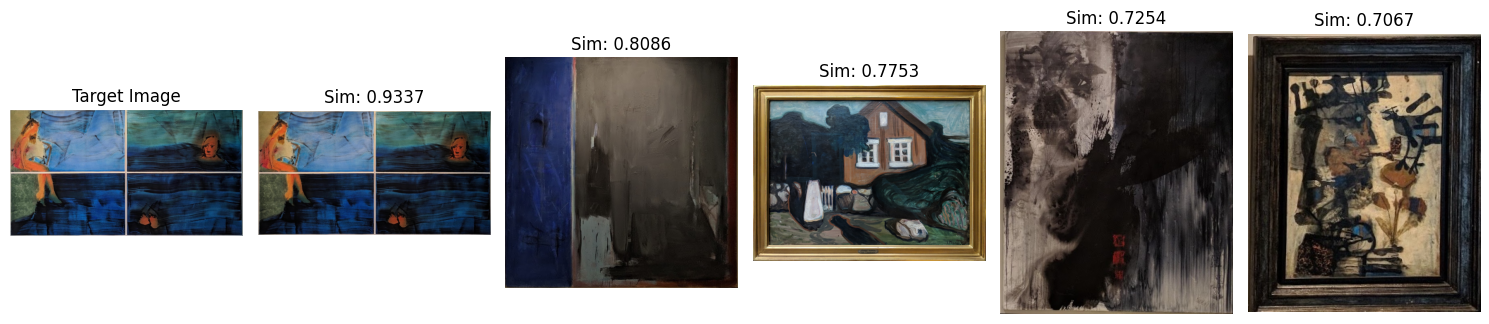

,image_path,artist,artwork_name,similarity
227,data/BBDD\bbdd_00227.jpg,Perico Pastor,Mezzo,0.933712
80,data/BBDD\bbdd_00080.jpg,NaN,NaN,0.808632
69,data/BBDD\bbdd_00069.jpg,Edvard Munch,House in Moonlight,0.775312
213,data/BBDD\bbdd_00213.jpg,NaN,NaN,0.725377
133,data/BBDD\bbdd_00133.jpg,Antoni Clave,Roi a l'oiseau,0.706735


In [14]:
find_similar_images(test_dataset["image"].iloc[3], dataset, top_n=5, plot=True, bins=BINS)

## Evaluation of bin number and distance metric

In [15]:
import pickle

# Load the ground-truth correspondence for each test image.
correspondence_path = os.path.join(TEST_DIR, "gt_corresps.pkl")
with open(correspondence_path, "rb") as file:
    correspondences = pickle.load(file)

# Each entry contains the zero-based index of the matching training image.
correspondence_indices = [
    match[0] if match else None
    for match in correspondences
]

train_rows = dataset.reset_index(drop=True)
test_rows = test_dataset[test_dataset["image"].apply(
    lambda img: isinstance(img, np.ndarray) and img.ndim == 3 and img.shape[2] == 3
)].reset_index(drop=True)
assert len(test_rows) == len(correspondence_indices), "test images and ground truth do not match"

correspondence_table = pd.DataFrame({
    "test_image": test_rows["image_path"],
    "train_index": correspondence_indices,
})
correspondence_table["train_image"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["image_path"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)
correspondence_table["artist"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["artist"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)
correspondence_table["artwork_name"] = correspondence_table["train_index"].apply(
    lambda index: train_rows.iloc[int(index)]["artwork_name"]
    if index is not None and 0 <= index < len(train_rows)
    else None
)

correspondence_table

,test_image,train_index,train_image,artist,artwork_name
0,data/qsd1_w1\00000.jpg,120,data/BBDD\bbdd_00120.jpg,Paul Klee,May come!
1,data/qsd1_w1\00001.jpg,170,data/BBDD\bbdd_00170.jpg,Alfred Figueras,Cap de Noia
2,data/qsd1_w1\00002.jpg,277,data/BBDD\bbdd_00277.jpg,Pere Santilari,Sifo groc
3,data/qsd1_w1\00003.jpg,227,data/BBDD\bbdd_00227.jpg,Perico Pastor,Mezzo
4,data/qsd1_w1\00004.jpg,251,data/BBDD\bbdd_00251.jpg,Francesc Artigau,Noia
5,data/qsd1_w1\00005.jpg,274,data/BBDD\bbdd_00274.jpg,Montserrat Clausells,Te de nit
6,data/qsd1_w1\00006.jpg,285,data/BBDD\bbdd_00285.jpg,Joan Hernandez Pijuan,Recordando una corrida
7,data/qsd1_w1\00007.jpg,258,data/BBDD\bbdd_00258.jpg,Sergi Barnils,"Mireu, tot ho faig nou"
8,data/qsd1_w1\00008.jpg,117,data/BBDD\bbdd_00117.jpg,Leticia Feduchi,Roba i cordill
9,data/qsd1_w1\00009.jpg,203,data/BBDD\bbdd_00203.jpg,Francesc Artigau,Retrat d'una noia


In [16]:
def create_bin_histograms(dataset, bins=BINS):
    """
    Return a copy of the dataset with a normalised histogram column computed with `bins` bins.
    """
    dataset = dataset.copy()
    dataset["histogram"] = dataset["image"].apply(lambda img: compute_histogram(img, bins))
    return dataset

In [17]:
binlist = [32, 64, 128, 256]

distance_metrics = {"Correlation": cv2.HISTCMP_CORREL,
                    "Intersect": cv2.HISTCMP_INTERSECT,
                    "Chi squared": cv2.HISTCMP_CHISQR,
                    "Battacharyya": cv2.HISTCMP_BHATTACHARYYA}

results = pd.DataFrame(columns=["bins", "distance_metric", "top1_accuracy", "top5_accuracy"])

# comparison using top 1 and top 5 accuracy with different histogram bin sizes
for bins in binlist:
    # Histograms only depend on the number of bins, so compute them once per bin size
    dataset_with_histograms = create_bin_histograms(dataset, bins=bins)

    for distance_metric, method in distance_metrics.items():
        print(f"Evaluating with {bins} bins and distance metric {distance_metric}:")

        top1_correct = 0
        top5_correct = 0
        total_images = len(test_rows)

        for idx, test_row in test_rows.iterrows():
            target_image = test_row["image"]
            true_path = correspondence_table.iloc[idx]["train_image"]
            similar_images = find_similar_images(target_image, dataset_with_histograms, top_n=5,
                                                 plot=False, bins=bins, method=method)

            # Check if the correct match is in the top 1
            if similar_images.iloc[0]["image_path"] == true_path:
                top1_correct += 1

            # Check if the correct match is in the top 5
            if true_path in similar_images["image_path"].values:
                top5_correct += 1

        top1_accuracy = top1_correct / total_images
        top5_accuracy = top5_correct / total_images

        results.loc[len(results)] = {
            "bins": bins,
            "distance_metric": distance_metric,
            "top1_accuracy": top1_accuracy,
            "top5_accuracy": top5_accuracy
        }

        print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
        print(f"Top-5 Accuracy: {top5_accuracy:.4f}\n")

results = results.astype({"bins": int, "top1_accuracy": float, "top5_accuracy": float})

Evaluating with 32 bins and distance metric Correlation:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 32 bins and distance metric Intersect:
Top-1 Accuracy: 0.3667
Top-5 Accuracy: 0.4667

Evaluating with 32 bins and distance metric Chi squared:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.3667

Evaluating with 32 bins and distance metric Battacharyya:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4333

Evaluating with 64 bins and distance metric Correlation:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4000

Evaluating with 64 bins and distance metric Intersect:
Top-1 Accuracy: 0.3333
Top-5 Accuracy: 0.4667

Evaluating with 64 bins and distance metric Chi squared:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.3000

Evaluating with 64 bins and distance metric Battacharyya:
Top-1 Accuracy: 0.3000
Top-5 Accuracy: 0.4333

Evaluating with 128 bins and distance metric Correlation:
Top-1 Accuracy: 0.2667
Top-5 Accuracy: 0.3667

Evaluating with 128 bins and distance metric Intersect:
Top-1 Acc

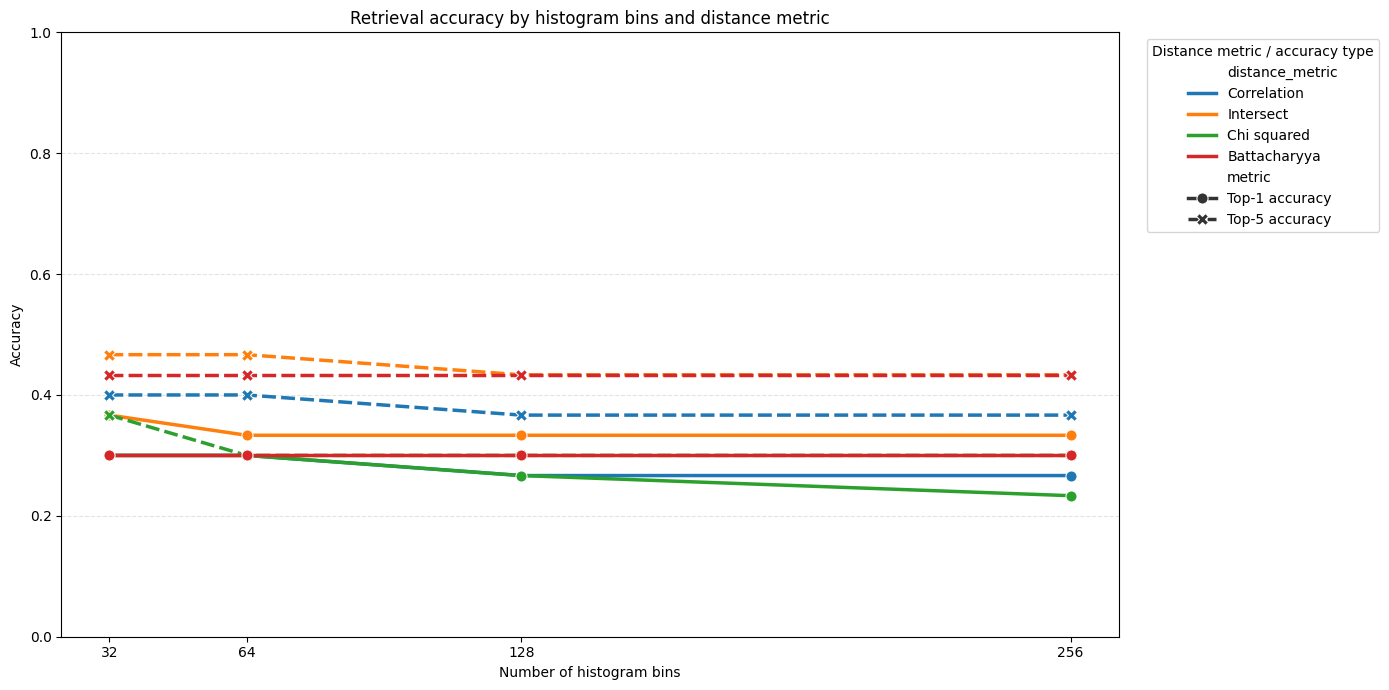

In [18]:
# Plot top-1 and top-5 accuracy for every distance metric and bin count
plot_data = results.melt(
    id_vars=["bins", "distance_metric"],
    value_vars=["top1_accuracy", "top5_accuracy"],
    var_name="metric",
    value_name="accuracy"
)
plot_data["metric"] = plot_data["metric"].map({
    "top1_accuracy": "Top-1 accuracy",
    "top5_accuracy": "Top-5 accuracy"
})

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=plot_data,
    x="bins",
    y="accuracy",
    hue="distance_metric",
    style="metric",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=8
)

plt.title("Retrieval accuracy by histogram bins and distance metric")
plt.xlabel("Number of histogram bins")
plt.ylabel("Accuracy")
plt.xticks(binlist)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Distance metric / accuracy type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()